# Quantum 2-to-1 Multiplexer (MUX)

**Topik:** Quantum 2-to-1 Multiplexer (MUX)  
> Sistem memilih satu dari dua input data berdasarkan nilai selector S,
> kemudian direpresentasikan sebagai rangkaian quantum reversible.

**Gerbang yang digunakan:** X (NOT), CNOT, Toffoli (CCX), Measurement

Instalasi & Import Library

In [1]:
# Install semua library
%pip install qiskit qiskit-aer schemdraw matplotlib numpy pandas -q
print("Semua library berhasil diinstall!")

Note: you may need to restart the kernel to use updated packages.
Semua library berhasil diinstall!



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Tabel Kebenaran & Fungsi Boolean MUX Klasik

### Fungsi Boolean
**Y = S'·I0 + S·I1**

- Jika **S = 0** --> output mengikuti **I0**
- Jika **S = 1** --> output mengikuti **I1**

### Penurunan K-Map
Minterm Y=1: m(2,3,5,7)  
- Grup 1: m(2,3) --> **S'·I0** (I1 don't care)  
- Grup 2: m(5,7) --> **S·I1** (I0 don't care)  

Hasil: **Y = S'·I0 + S·I1**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import schemdraw
import schemdraw.elements as elm



from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Semua import berhasil!")

Semua import berhasil!


In [3]:
# TABEL KEBENARAN MUX 2-to-1
# Y = S'·I0 + S·I1

data = []
for S in [0, 1]:
    for I0 in [0, 1]:
        for I1 in [0, 1]:
            S_not = 1 - S
            term1 = S_not & I0
            term2 = S & I1
            Y = term1 | term2   
            data.append({
                'S (Selector)': S,
                'I0 (Input 0)': I0,
                'I1 (Input 1)': I1,
                "S' (NOT S)": S_not,
                "S'·I0": term1,
                "S·I1": term2,
                'Y (Output)': Y
            })

df = pd.DataFrame(data)
print('='*62)
print('   TABEL KEBENARAN MUX 2-to-1')
print("   Fungsi Boolean: Y = S'·I0 + S·I1")
print('='*62)
print(df.to_string(index=False))
print('='*62)
print('\nMinterm: Sum m(2, 3, 5, 7)')

   TABEL KEBENARAN MUX 2-to-1
   Fungsi Boolean: Y = S'·I0 + S·I1
 S (Selector)  I0 (Input 0)  I1 (Input 1)  S' (NOT S)  S'·I0  S·I1  Y (Output)
            0             0             0           1      0     0           0
            0             0             1           1      0     0           0
            0             1             0           1      1     0           1
            0             1             1           1      1     0           1
            1             0             0           0      0     0           0
            1             0             1           0      0     1           1
            1             1             0           0      0     0           0
            1             1             1           0      0     1           1

Minterm: Sum m(2, 3, 5, 7)


## Bagian 3: Rangkaian Logika Klasik (SchemDraw Screenshot)

Komponen: NOT gate, AND gate (x2), OR gate  
Fungsi: Y = S'·I0 + S·I1

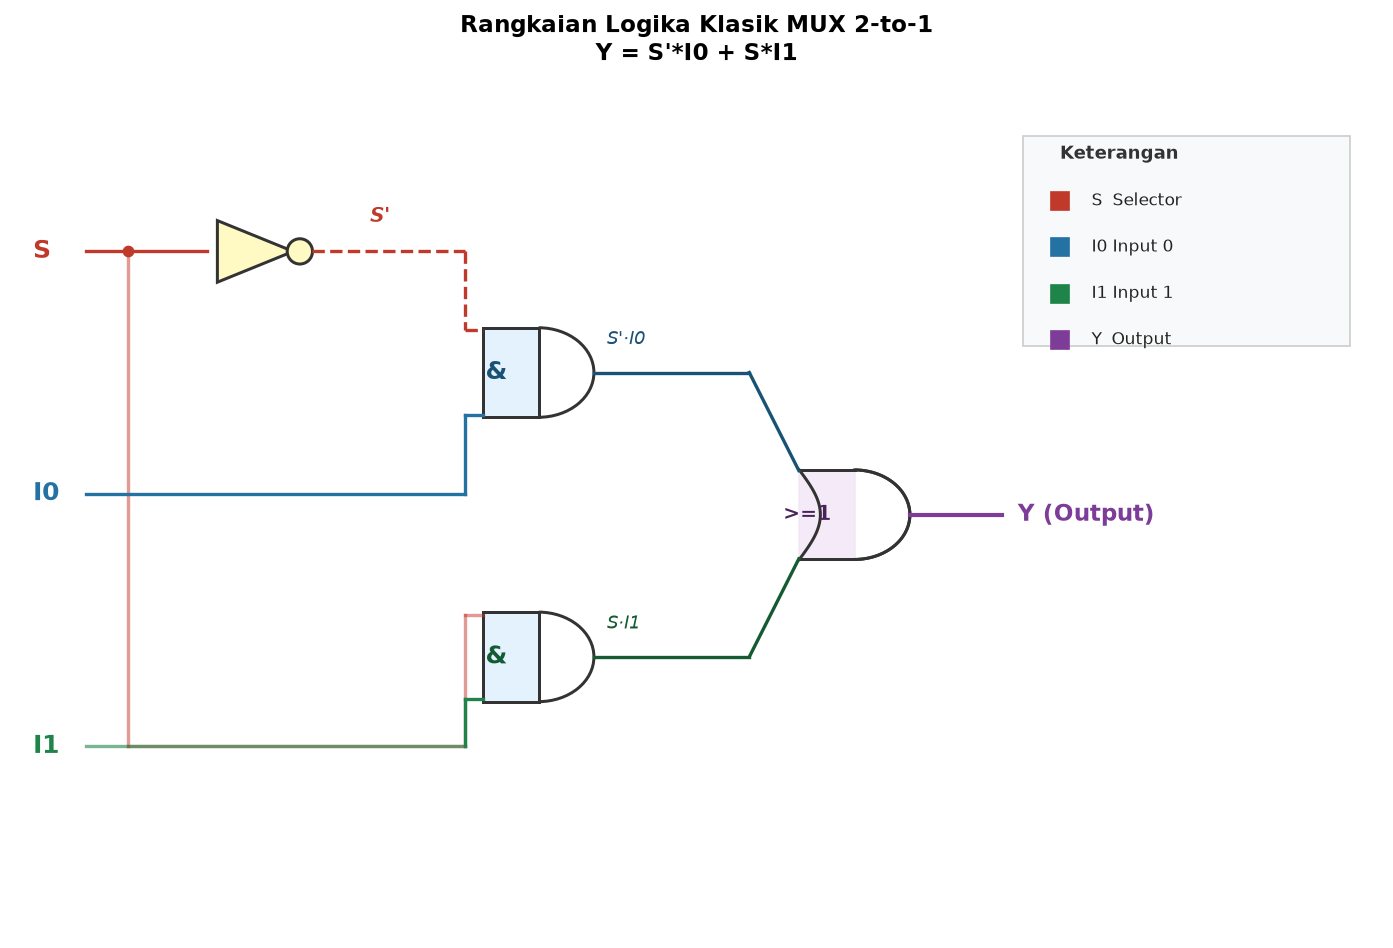

Screenshot rangkaian klasik disimpan: classical_mux_circuit.png


In [4]:
# RANGKAIAN LOGIKA KLASIK MUX 2-to-1

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13); ax.set_ylim(0, 8)
ax.set_aspect('equal'); ax.axis('off')
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax.set_title("Rangkaian Logika Klasik MUX 2-to-1\nY = S'*I0 + S*I1",
             fontsize=14, fontweight='bold', pad=20)

from matplotlib.patches import Arc

def draw_not(ax, x, y, s=0.45):
    tri = plt.Polygon([[x-s,y-s*0.65],[x-s,y+s*0.65],[x+s*0.6,y]],
                       fill=True, facecolor='#FFF9C4', edgecolor='#333', lw=1.8)
    ax.add_patch(tri)
    c = plt.Circle((x+s*0.74,y),0.12,fill=True,facecolor='#FFF9C4',edgecolor='#333',lw=1.8)
    ax.add_patch(c)
    return x-s, x+s*0.74+0.12

def draw_and(ax, x, y, w=1.05, h=0.85):
    poly = plt.Polygon([[x-w/2,y-h/2],[x,y-h/2],[x,y+h/2],[x-w/2,y+h/2]],
                        fill=True, facecolor='#E3F2FD', edgecolor='#333', lw=1.8)
    ax.add_patch(poly)
    arc = Arc((x,y),w,h,angle=0,theta1=-90,theta2=90,color='#333',lw=1.8)
    ax.add_patch(arc)
    return x-w/2, x+w/2

def draw_or(ax, x, y, w=1.05, h=0.85):
    import numpy as np
    theta = np.linspace(-np.pi/2, np.pi/2, 60)
    ax.plot(x + w/2*np.cos(theta), y + h/2*np.sin(theta), '-', color='#333', lw=1.8)
    t = np.linspace(0,1,40)
    ax.plot(x-w/2+0.2*np.sin(np.pi*t), y-h/2+h*t, '-', color='#333', lw=1.8)
    ax.fill([x-w/2,x,x,x-w/2],[y-h/2,y-h/2,y+h/2,y+h/2],color='#F3E5F5',alpha=0.8)
    ax.plot([x-w/2,x],[y+h/2,y+h/2],'-',color='#333',lw=1.8)
    ax.plot([x-w/2,x],[y-h/2,y-h/2],'-',color='#333',lw=1.8)
    arc = Arc((x,y),w,h,angle=0,theta1=-90,theta2=90,color='#333',lw=1.8)
    ax.add_patch(arc)
    return x-w/2, x+w/2

lw = 2.0
cS='#C0392B'; cI0='#2471A3'; cI1='#1E8449'; cOut='#7D3C98'

# Input labels
ax.text(0.2,6.5,'S', fontsize=15,fontweight='bold',color=cS,va='center')
ax.text(0.2,4.2,'I0',fontsize=15,fontweight='bold',color=cI0,va='center')
ax.text(0.2,1.8,'I1',fontsize=15,fontweight='bold',color=cI1,va='center')

# S wire -> NOT gate
ax.plot([0.7,1.85],[6.5,6.5],'-',color=cS,lw=lw)
_, nout = draw_not(ax, 2.4, 6.5)
ax.plot([nout,4.3],[6.5,6.5],'--',color=cS,lw=lw)
ax.text(3.4,6.78,"S'",fontsize=12,color=cS,style='italic',fontweight='bold')

# S branch down
ax.plot([1.1,1.1],[6.5,1.8],'-',color=cS,lw=lw,alpha=0.5)
ax.plot(1.1,6.5,'o',color=cS,markersize=6)

# I0 wire
ax.plot([0.7,4.3],[4.2,4.2],'-',color=cI0,lw=lw)

# AND gate 1 (S'*I0) at x=5.0, y=5.35
_, aout1 = draw_and(ax, 5.0, 5.35)
ax.text(4.6,5.35,'&',fontsize=15,ha='center',va='center',color='#1A5276',fontweight='bold')
ax.text(5.65,5.62,"S'·I0",fontsize=11,color='#1A5276',style='italic')
ax.plot([4.3,4.3],[6.5,5.75],'--',color=cS,lw=lw)
ax.plot([4.3,4.475],[5.75,5.75],'--',color=cS,lw=lw)
ax.plot([4.3,4.3],[4.2,4.95],'-',color=cI0,lw=lw)
ax.plot([4.3,4.475],[4.95,4.95],'-',color=cI0,lw=lw)
ax.plot([aout1,7.0],[5.35,5.35],'-',color='#1A5276',lw=lw)

# AND gate 2 (S*I1) at x=5.0, y=2.65
_, aout2 = draw_and(ax, 5.0, 2.65)
ax.text(4.6,2.65,'&',fontsize=15,ha='center',va='center',color='#145A32',fontweight='bold')
ax.text(5.65,2.92,"S·I1",fontsize=11,color='#145A32',style='italic')
ax.plot([1.1,4.3],[1.8,1.8],'-',color=cS,lw=lw,alpha=0.5)
ax.plot([0.7,4.3],[1.8,1.8],'-',color=cI1,lw=lw,alpha=0.6)
ax.plot([4.3,4.3],[1.8,3.05],'-',color=cS,lw=lw,alpha=0.5)
ax.plot([4.3,4.475],[3.05,3.05],'-',color=cS,lw=lw,alpha=0.5)
ax.plot([4.3,4.3],[1.8,2.25],'-',color=cI1,lw=lw)
ax.plot([4.3,4.475],[2.25,2.25],'-',color=cI1,lw=lw)
ax.plot([aout2,7.0],[2.65,2.65],'-',color='#145A32',lw=lw)

# OR gate at x=8.0, y=4.0
_, orout = draw_or(ax, 8.0, 4.0)
ax.text(7.55,4.0,'>=1',fontsize=12,ha='center',va='center',color='#4A235A',fontweight='bold')
ax.plot([7.0,7.47],[5.35,4.42],'-',color='#1A5276',lw=lw)
ax.plot([7.0,7.47],[2.65,3.58],'-',color='#145A32',lw=lw)
ax.plot([orout,9.4],[4.0,4.0],'-',color=cOut,lw=2.5)
ax.text(9.55,4.0,'Y (Output)',fontsize=14,fontweight='bold',color=cOut,va='center')

# Legend
leg=[('#C0392B','S  Selector'),('#2471A3','I0 Input 0'),
     ('#1E8449','I1 Input 1'),('#7D3C98','Y  Output')]
ax.add_patch(plt.Rectangle((9.6,5.6),3.1,2.0,fill=True,facecolor='#F8F9FA',
                              edgecolor='#CCC',lw=1,zorder=3))
ax.text(9.95,7.38,'Keterangan',fontsize=11,fontweight='bold',color='#333')
for i,(c,lbl) in enumerate(leg):
    ax.plot(9.95,6.98-i*0.44,'s',color=c,markersize=11,zorder=4)
    ax.text(10.25,6.98-i*0.44,lbl,fontsize=10,va='center',color='#222')

plt.tight_layout()
plt.savefig('classical_mux_circuit.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Screenshot rangkaian klasik disimpan: classical_mux_circuit.png")


## Bagian 4: Pemetaan ke Gerbang Kuantum

### Mapping: Klasik ke Kuantum

| Gerbang Klasik | Gerbang Kuantum | Keterangan |
|:--------------:|:---------------:|------------|
| NOT | X Gate | Membalik qubit |0> ke |1> |
| AND | Toffoli (CCX) | Reversible AND -- butuh ancilla |
| OR | CNOT | XOR = OR jika mutual exclusive |

### Desain Qubit
```
q[0] = S       <- Selector input
q[1] = I0      <- Data input 0
q[2] = I1      <- Data input 1
q[3] = anc1    <- Ancilla: menyimpan S'·I0
q[4] = anc2    <- OUTPUT Y  <- diukur
```

### Alur Komputasi
```
Step 1: X(q[0])                 -> S menjadi S' sementara
        Toffoli(q[0],q[1],q[3]) -> anc1 = S'·I0
        X(q[0])                 -> S dikembalikan

Step 2: Toffoli(q[0],q[2],q[4]) -> anc2 = S·I1

Step 3: CNOT(q[3],q[4])         -> anc2 = Y (XOR = OR jika mutual exclusive)

Step 4: Measure q[4]            -> output Y
```

## Bagian 5: Implementasi Quantum Circuit (Qiskit)

In [5]:
# QUANTUM MUX 2-to-1 -- Implementasi Qiskit

def build_mux_circuit(S_val, I0_val, I1_val):
    """
    Build quantum circuit MUX 2-to-1.
    q[0]=S, q[1]=I0, q[2]=I1, q[3]=anc1(S'·I0), q[4]=anc2(Y)
    """
    qr = QuantumRegister(5, 'q')
    cr = ClassicalRegister(1, 'y')
    qc = QuantumCircuit(qr, cr)

    # Inisialisasi input
    if S_val  == 1: qc.x(qr[0])
    if I0_val == 1: qc.x(qr[1])
    if I1_val == 1: qc.x(qr[2])
    qc.barrier(label='Init')

    # S'·I0: Flip S -> Toffoli -> Flip S kembali
    qc.x(qr[0])               # S -> S'
    qc.ccx(qr[0], qr[1], qr[3])  # anc1 = S'·I0
    qc.x(qr[0])               # S' -> S (restore)
    qc.barrier(label="S'·I0")

    # S·I1
    qc.ccx(qr[0], qr[2], qr[4])  # anc2 = S·I1
    qc.barrier(label='S·I1')

    # OR: Y = S'·I0 XOR S·I1
    qc.cx(qr[3], qr[4])          # anc2 = anc2 XOR anc1 = Y
    qc.barrier(label='Y=OR')

    # Measure output
    qc.measure(qr[4], cr[0])
    return qc

# Contoh: S=1, I0=0, I1=1 -> Expected Y=1
print('='*55)
print('  Contoh: S=1, I0=0, I1=1  ->  Expected Y = 1')
print('='*55)
qc_demo = build_mux_circuit(1, 0, 1)
print(qc_demo.draw(output='text', fold=80))
print(f'\n  Jumlah qubit  : {qc_demo.num_qubits}')
print(f'  Jumlah gerbang: {qc_demo.size()}')
print(f'  Depth circuit : {qc_demo.depth()}')

  Contoh: S=1, I0=0, I1=1  ->  Expected Y = 1
     ┌───┐ Init ┌───┐     ┌───┐ S'·I0       S·I1       Y=OR    
q_0: ┤ X ├──░───┤ X ├──■──┤ X ├───░─────■────░──────────░──────
     └───┘  ░   └───┘  │  └───┘   ░     │    ░          ░      
q_1: ───────░──────────■──────────░─────┼────░──────────░──────
     ┌───┐  ░          │          ░     │    ░          ░      
q_2: ┤ X ├──░──────────┼──────────░─────■────░──────────░──────
     └───┘  ░        ┌─┴─┐        ░     │    ░          ░      
q_3: ───────░────────┤ X ├────────░─────┼────░─────■────░──────
            ░        └───┘        ░   ┌─┴─┐  ░   ┌─┴─┐  ░   ┌─┐
q_4: ───────░─────────────────────░───┤ X ├──░───┤ X ├──░───┤M├
            ░                     ░   └───┘  ░   └───┘  ░   └╥┘
y: 1/════════════════════════════════════════════════════════╩═
                                                             0 

  Jumlah qubit  : 5
  Jumlah gerbang: 8
  Depth circuit : 7


In [6]:
%pip install pylatexenc -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Visualisasi quantum circuit
fig = qc_demo.draw(output='mpl', style='bw', fold=20)
plt.suptitle('Quantum MUX Circuit -- S=1, I0=0, I1=1  (Expected Y=1)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('quantum_mux_circuit.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Screenshot quantum circuit disimpan: quantum_mux_circuit.png')

<Figure size 768x576 with 0 Axes>

Screenshot quantum circuit disimpan: quantum_mux_circuit.png


## Bagian 6: Simulasi & Measurement (Qiskit Aer Simulator)

In [8]:
simulator = AerSimulator()
results_quantum = []

print('='*65)
print('  SIMULASI QUANTUM MUX -- Semua Kombinasi Input (1024 shots)')
print('='*65)
print(f"  {'S':>3}  {'I0':>4}  {'I1':>4}  |  {'Y_klasik':>8}  |  {'Y_quantum':>9}  |  Status")
print('-'*65)

for S in [0, 1]:
    for I0 in [0, 1]:
        for I1 in [0, 1]:
            Y_klasik = (1 - S) * I0 + S * I1
            qc = build_mux_circuit(S, I0, I1)
            job = simulator.run(qc, shots=1024)
            counts = job.result().get_counts()
            Y_quantum = int(max(counts, key=counts.get))
            match = (Y_klasik == Y_quantum)
            results_quantum.append({
                'S': S, 'I0': I0, 'I1': I1,
                'Y_klasik': Y_klasik, 'Y_quantum': Y_quantum,
                'counts': counts, 'match': match
            })
            status = 'MATCH OK' if match else 'MISMATCH!'
            print(f"  {S:>3}  {I0:>4}  {I1:>4}  |  {Y_klasik:>8}  |  {Y_quantum:>9}  |  {status}")

print('='*65)
match_count = sum(1 for r in results_quantum if r['match'])
total = len(results_quantum)
print(f'\nAkurasi: {match_count}/{total} = {match_count/total*100:.0f}%')

  SIMULASI QUANTUM MUX -- Semua Kombinasi Input (1024 shots)
    S    I0    I1  |  Y_klasik  |  Y_quantum  |  Status
-----------------------------------------------------------------
    0     0     0  |         0  |          0  |  MATCH OK
    0     0     1  |         0  |          0  |  MATCH OK
    0     1     0  |         1  |          1  |  MATCH OK
    0     1     1  |         1  |          1  |  MATCH OK
    1     0     0  |         0  |          0  |  MATCH OK
    1     0     1  |         1  |          1  |  MATCH OK
    1     1     0  |         0  |          0  |  MATCH OK
    1     1     1  |         1  |          1  |  MATCH OK

Akurasi: 8/8 = 100%


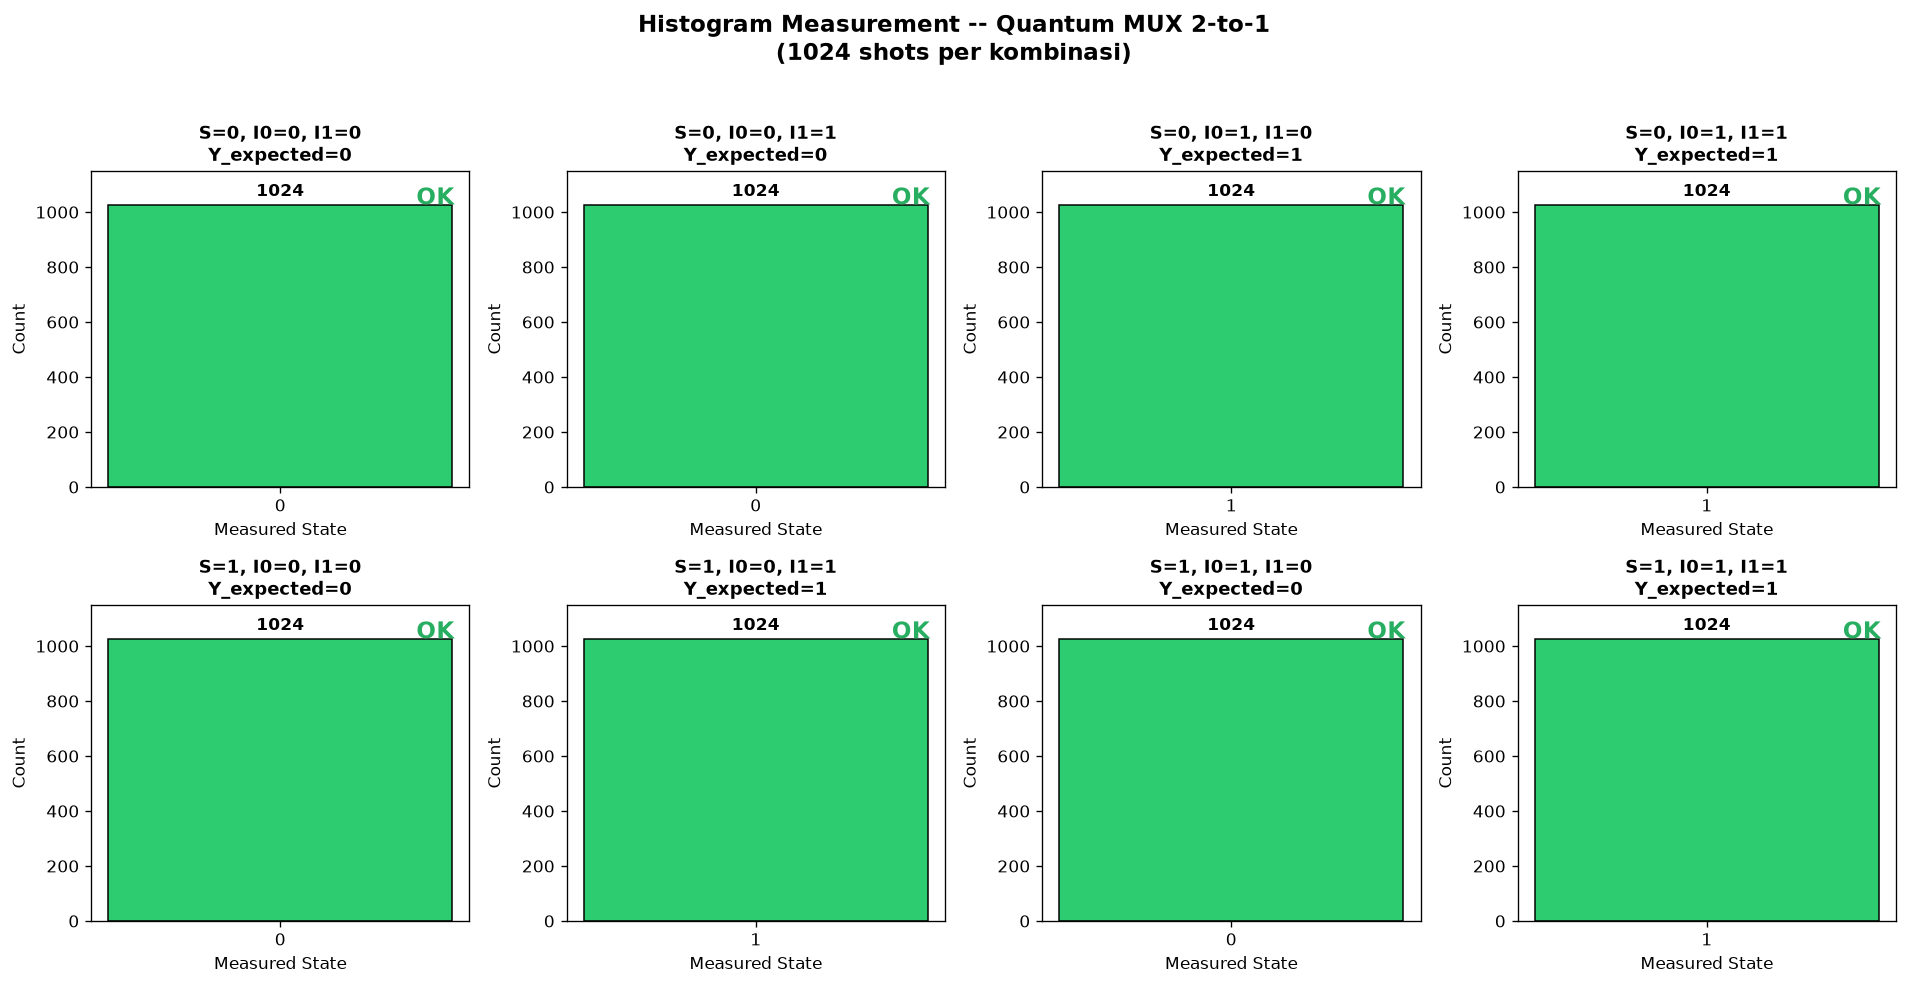

Histogram disimpan: measurement_histogram.png


In [9]:
# HISTOGRAM -- Semua 8 Kombinasi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Histogram Measurement -- Quantum MUX 2-to-1\n(1024 shots per kombinasi)',
             fontsize=14, fontweight='bold', y=1.02)

for idx, r in enumerate(results_quantum):
    ax = axes[idx // 4][idx % 4]
    counts = r['counts']
    labels = sorted(counts.keys())
    values = [counts[l] for l in labels]
    colors = ['#2ECC71' if l == str(r['Y_klasik']) else '#E74C3C' for l in labels]
    bars = ax.bar(labels, values, color=colors, edgecolor='black', lw=0.9, width=0.5)
    ax.set_title(f"S={r['S']}, I0={r['I0']}, I1={r['I1']}\nY_expected={r['Y_klasik']}",
                  fontsize=11, fontweight='bold')
    ax.set_xlabel('Measured State', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_ylim(0, 1150)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, val+20, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    sc = '#27AE60' if r['match'] else '#C0392B'
    ax.text(0.96, 0.95, 'OK' if r['match'] else 'X',
             transform=ax.transAxes, fontsize=14, fontweight='bold',
             color=sc, ha='right', va='top')

plt.tight_layout()
plt.savefig('measurement_histogram.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Histogram disimpan: measurement_histogram.png')

## Bagian 7: Validasi & Analisis

In [10]:
# TABEL VALIDASI
df_val = pd.DataFrame([{
    'S': r['S'], 'I0': r['I0'], 'I1': r['I1'],
    'Y Klasik': r['Y_klasik'],
    'Y Quantum': r['Y_quantum'],
    'Match?': 'Ya' if r['match'] else 'Tidak'
} for r in results_quantum])

print('='*55)
print('  TABEL VALIDASI -- Klasik vs Quantum')
print('='*55)
print(df_val.to_string(index=False))
print('='*55)
print(f'\nAkurasi: {match_count}/{total} = {match_count/total*100:.0f}%')

  TABEL VALIDASI -- Klasik vs Quantum
 S  I0  I1  Y Klasik  Y Quantum Match?
 0   0   0         0          0     Ya
 0   0   1         0          0     Ya
 0   1   0         1          1     Ya
 0   1   1         1          1     Ya
 1   0   0         0          0     Ya
 1   0   1         1          1     Ya
 1   1   0         0          0     Ya
 1   1   1         1          1     Ya

Akurasi: 8/8 = 100%


In [11]:
# JAWABAN 6 PERTANYAAN ANALISIS LAPORAN

print('='*62)
print('  ANALISIS LAPORAN -- Quantum 2-to-1 MUX')
print('='*62)

print('''
1) Fungsi selector S pada MUX klasik:
   S = 0 --> Y = I0  (memilih Input 0, karena S'=1 sehingga S'·I0 aktif)
   S = 1 --> Y = I1  (memilih Input 1, karena S=1 sehingga S·I1 aktif)
   S bekerja seperti switch yang memilih jalur data secara eksklusif.
''')

print('''
2) Penurunan fungsi Boolean Y = S'·I0 + S·I1:
   Dari tabel kebenaran, minterm Y=1: m(2,3,5,7)
   K-Map 3 variabel (S, I0, I1):
     Grup 1 -- m(2,3): S'·I0  (I1 don't care)
     Grup 2 -- m(5,7): S·I1   (I0 don't care)
   Hasil: Y = S'·I0 + S·I1
''')

print('''
3) Mengapa quantum MUX butuh qubit ancilla?
   Quantum circuit HARUS reversible (unitary).
   AND klasik: 2 input -> 1 output (tidak reversible, informasi hilang).
   Toffoli gate: CCX(A,B,anc=0) -> anc = A·B, A dan B tetap ada.
   Ancilla menyimpan hasil intermediate tanpa membuang informasi.
   Ini sesuai Landauer's principle dalam termodinamika komputasi.
''')

print('''
4) Bagaimana Toffoli merepresentasikan pemilihan input?
   Toffoli: target = target XOR (ctrl1 AND ctrl2)
   Jika target = |0>: target = ctrl1 AND ctrl2

   [S'·I0]: X(q0) -> CCX(q0,q1,anc1) -> X(q0)
     q0 diflip jadi S', Toffoli mengisi anc1=S'·I0, q0 dikembalikan.

   [S·I1]:  CCX(q0,q2,anc2) -> anc2 = S·I1

   [OR]:    CX(anc1,anc2)
     S'·I0 dan S·I1 mutual exclusive -> XOR = OR -> anc2 = Y
''')

print('5) Perbandingan measurement vs tabel kebenaran klasik:')
print(df_val.to_string(index=False))
print(f'   Akurasi: {match_count}/{total} = {match_count/total*100:.0f}%')
print('   Semua kombinasi cocok antara quantum dan klasik.')

print('''
6) Perbedaan MUX klasik vs MUX reversible:

   Aspek               MUX Klasik          MUX Reversible
   Reversibilitas      Tidak reversible    Sepenuhnya reversible
   Jumlah output       1 (Y saja)          Multiple (input+ancilla)
   Gerbang             NOT, AND, OR        X, CNOT, Toffoli
   Energi dissipasi    Ada (Landauer)      Nol (teori)
   Superposisi         Tidak bisa          Bisa (quantum advantage)
   Entanglement        Tidak ada           Dimungkinkan
   Aplikasi            Digital logic       Quantum computing
''')

  ANALISIS LAPORAN -- Quantum 2-to-1 MUX

1) Fungsi selector S pada MUX klasik:
   S = 0 --> Y = I0  (memilih Input 0, karena S'=1 sehingga S'·I0 aktif)
   S = 1 --> Y = I1  (memilih Input 1, karena S=1 sehingga S·I1 aktif)
   S bekerja seperti switch yang memilih jalur data secara eksklusif.


2) Penurunan fungsi Boolean Y = S'·I0 + S·I1:
   Dari tabel kebenaran, minterm Y=1: m(2,3,5,7)
   K-Map 3 variabel (S, I0, I1):
     Grup 1 -- m(2,3): S'·I0  (I1 don't care)
     Grup 2 -- m(5,7): S·I1   (I0 don't care)
   Hasil: Y = S'·I0 + S·I1


3) Mengapa quantum MUX butuh qubit ancilla?
   Quantum circuit HARUS reversible (unitary).
   AND klasik: 2 input -> 1 output (tidak reversible, informasi hilang).
   Toffoli gate: CCX(A,B,anc=0) -> anc = A·B, A dan B tetap ada.
   Ancilla menyimpan hasil intermediate tanpa membuang informasi.
   Ini sesuai Landauer's principle dalam termodinamika komputasi.


4) Bagaimana Toffoli merepresentasikan pemilihan input?
   Toffoli: target = target XOR (ctr

## Ringkasan & File Output

| File | Keterangan |
|------|------------|
| `classical_mux_circuit.png` | Rangkaian logika klasik (NOT+AND+OR) |
| `quantum_mux_circuit.png` | Quantum circuit Qiskit |
| `measurement_histogram.png` | Histogram simulasi 8 kombinasi |

**Referensi:**
- Qiskit Documentation: https://docs.quantum.ibm.com
- Nielsen & Chuang, *Quantum Computation and Quantum Information* (2000)
- SchemDraw: https://schemdraw.readthedocs.io
- Landauer, R. (1961). *Irreversibility and heat generation in the computing process.*